In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical
import re
import string

# Set random seed for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

2025-12-04 10:07:11.728926: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-12-04 10:07:11.833081: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-04 10:07:15.112638: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
import kagglehub
import pandas as pd
import zipfile
import os

# Download the dataset
path = kagglehub.dataset_download("tgdivy/poetry-foundation-poems")

# Find the CSV file
csv_file = None
for root, dirs, files in os.walk(path):
    for file in files:
        if file.endswith('.csv'):
            csv_file = os.path.join(root, file)
            break

if csv_file:
    # If it's a zip, extract
    if csv_file.endswith('.zip'):
        with zipfile.ZipFile(csv_file, 'r') as zip_ref:
            zip_ref.extractall(path)
            csv_file = csv_file.replace('.zip', '.csv')
    
    # Load the CSV
    df = pd.read_csv(csv_file, encoding='latin1', on_bad_lines='skip', engine='python')
    print("First 5 records:", df.head())
    print("Columns:", df.columns)
else:
    print("CSV file not found in the dataset.")

/home/chloycosta/Documents/College_code/Sem_5/NNDL/.venv/lib64/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


First 5 records:    Unnamed: 0                                              Title  \
0           0  \r\r\n                    Objects Used to Prop...   
1           1  \r\r\n                    The New Church\r\r\n...   
2           2  \r\r\n                    Look for Me\r\r\n   ...   
3           3  \r\r\n                    Wild Life\r\r\n     ...   
4           4  \r\r\n                    Umbrella\r\r\n      ...   

                                                Poem              Poet Tags  
0  \r\r\nDog bone, stapler,\r\r\ncribbage board, ...  Michelle Menting  NaN  
1  \r\r\nThe old cupola glinted above the clouds,...     Lucia Cherciu  NaN  
2  \r\r\nLook for me under the hood\r\r\nof that ...        Ted Kooser  NaN  
3  \r\r\nBehind the silo, the Mother Rabbit\r\r\n...   Grace Cavalieri  NaN  
4  \r\r\nWhen I push your button\r\r\nyou fly off...      Connie Wanek  NaN  
Columns: Index(['Unnamed: 0', 'Title', 'Poem', 'Poet', 'Tags'], dtype='object')


In [3]:
# Concatenate poems into a single text corpus
if 'df' in locals():
    # Assuming the poem content is in a column like 'Content' or 'Poem'
    # From the dataset description, it has Title, Poet, Tags, Poem
    poem_column = 'Poem'  # Adjust if necessary
    if poem_column in df.columns:
        corpus = '\n'.join(df[poem_column].dropna().astype(str))
        print(f"Total corpus length: {len(corpus)} characters")
        print("Sample corpus:", corpus[:500])
    else:
        print("Poem column not found. Available columns:", df.columns)

Total corpus length: 21055266 characters
Sample corpus: 
Dog bone, stapler,
cribbage board, garlic press
     because this window is looseâlacks
suction, lacks grip.
Bungee cord, bootstrap,
dog leash, leather belt
     because this window had sash cords.
They frayed. They broke.
Feather duster, thatch of straw, empty
bottle of Elmer's glue
     because this window is loudâits hinges clack
open, clack shut.
Stuffed bear, baby blanket,
single crib newel
     because this window is split. It's dividing
in two.
Velve


In [4]:
# Data Preprocessing
if 'corpus' in locals():
    # Convert to lowercase
    corpus = corpus.lower()

    # Remove punctuation and special characters
    corpus = re.sub(r'[^\w\s]', '', corpus)

    # Tokenize the text, limit vocabulary
    vocab_size = 5000  # Limit vocabulary size
    tokenizer = Tokenizer(num_words=vocab_size)
    tokenizer.fit_on_texts([corpus])
    total_words = min(vocab_size, len(tokenizer.word_index) + 1)
    print(f"Total unique words (limited): {total_words}")

    # Create sequences with sliding window, limit sequence length
    seq_length = 50  # Fixed sequence length
    max_sequence_len = seq_length + 1
    input_sequences = []
    words = corpus.split()
    for i in range(seq_length, len(words)):
        seq = words[i-seq_length:i+1]
        input_sequences.append(tokenizer.texts_to_sequences([seq])[0])

    # Limit number of sequences to avoid memory issues
    max_sequences = 50000  # Adjust as needed
    input_sequences = input_sequences[:max_sequences]

    # Pad sequences
    input_sequences = np.array(pad_sequences(input_sequences, maxlen=max_sequence_len, padding='pre'))

    # Create predictors and label
    X = input_sequences[:, :-1]
    y = input_sequences[:, -1]
    y = to_categorical(y, num_classes=total_words)

    print(f"X shape: {X.shape}")
    print(f"y shape: {y.shape}")

Total unique words (limited): 5000
X shape: (50000, 50)
y shape: (50000, 5000)


In [5]:
# Build the LSTM model
if 'X' in locals():
    model = Sequential()
    model.add(Embedding(total_words, 100, input_length=max_sequence_len-1))
    model.add(LSTM(100))
    model.add(Dropout(0.2))
    model.add(Dense(total_words, activation='softmax'))

    model.build(input_shape=(None, max_sequence_len-1))

    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    model.summary()

/home/chloycosta/Documents/College_code/Sem_5/NNDL/.venv/lib64/python3.11/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
2025-12-04 10:08:32.436060: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 50, 100)        │       500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 100)            │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5000)           │       505,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,085,400 (4.14 MB)

 Trainable params: 1,085,400 (4.14 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# Train the model
if 'model' in locals():
    history = model.fit(X, y, epochs=20, verbose=1)

2025-12-04 10:08:36.215895: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 1000000000 exceeds 10% of free system memory.


Epoch 1/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 54s 33ms/step - accuracy: 0.0884 - loss: 6.2330
Epoch 2/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 52s 33ms/step - accuracy: 0.1029 - loss: 5.8601
Epoch 3/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 54s 35ms/step - accuracy: 0.1134 - loss: 5.6620
Epoch 4/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 50s 32ms/step - accuracy: 0.1208 - loss: 5.4880
Epoch 5/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 50s 32ms/step - accuracy: 0.1288 - loss: 5.3292
Epoch 6/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 46s 29ms/step - accuracy: 0.1395 - loss: 5.1610
Epoch 7/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 48s 31ms/step - accuracy: 0.1492 - loss: 4.9920
Epoch 8/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 45s 29ms/step - accuracy: 0.1621 - loss: 4.8121
Epoch 9/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 48s 31ms/step - accuracy: 0.1745 - loss: 4.6360
Epoch 10/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 51s 33ms/step - accuracy: 0.1898 - loss: 4.4695
Epoch 11/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 48s 30ms/step - accuracy: 0.2058 - loss: 4.3003
Epoch 12

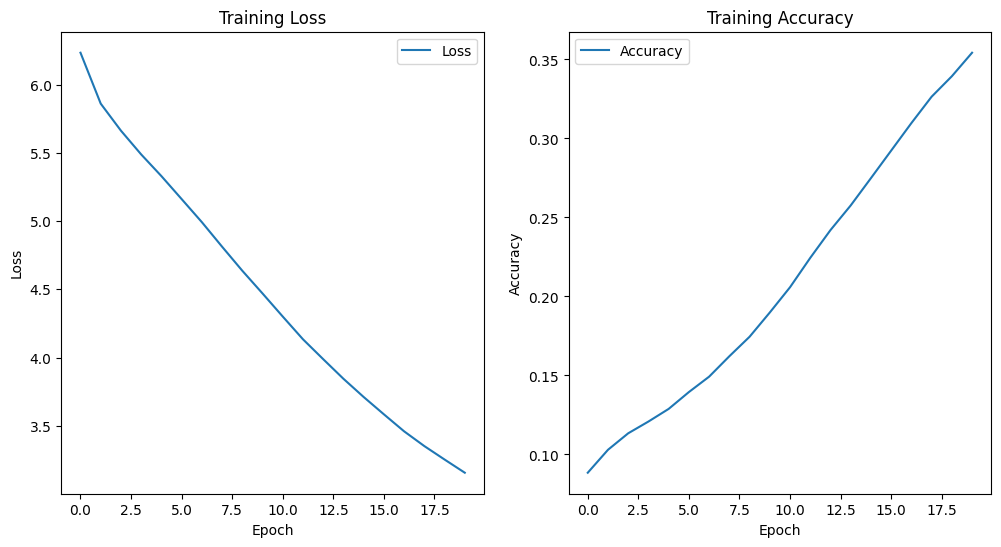

In [7]:
# Plot training loss and accuracy
if 'history' in locals():
    import matplotlib.pyplot as plt
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Loss')
    plt.title('Training Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Accuracy')
    plt.title('Training Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

In [8]:
# Text Generation Function
def generate_poetry(seed_text, next_words, model, max_sequence_len):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_sequence_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list), axis=-1)
        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

# Generate poetry
if 'model' in locals():
    seed_texts = ["the moon", "love is", "in the forest"]
    for seed in seed_texts:
        generated = generate_poetry(seed, 10, model, max_sequence_len)
        print(f"Seed: '{seed}' -> Generated: '{generated}'")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 269ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
Seed: 'the moon' -> Generated: 'the moon to be a kind of a map pinned and in'
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Seed: 'love is' -> Generated: 'love is to be a kind of a map that says a'
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━